# Capstone — Can a learned CTR benchmark improve editorial review prioritization?

**Author:** Orbin Sunny · **Assignments:** ML-11 paper / ML-12 communication · **Date:** 4 October 2026 · **Lane:** CTR opportunity scoring.

This executed notebook assembles the main starter-snapshot study and the paper. Prepared with AI assistance. It runs the existing model, audit and playbook in order, checks their evidence, and rebuilds the public page. The separate warehouse contract is linked as saved development evidence and is not rerun here.

**Paper:** https://orbin123.github.io/flyrank-ml-internship/ · **Repo:** https://github.com/orbin123/flyrank-ml-internship

## Abstract

This FlyRank case study asks whether a learned CTR benchmark can help editors decide which visible but low-click content to inspect first, compared with a transparent peer rule. It uses a 30,000-page anonymized starter snapshot, retaining 12,009 pages across 28 clients under an explicit exposure and position policy. A shallow tree and random forest estimate same-window observed CTR using three allowlisted features, with training-only peers and disjoint client validation. The peer rule wins validation and records test weighted MAE of 0.383436 percentage points versus 0.385521 for the forest, while a later grouped audit favors a naive pooled-CTR reference. For FlyRank's content-review problem, the result supports a cautious human-reviewed triage queue rather than model promotion; independent editorial usefulness, future performance and causal edit benefits remain unmeasured.

## 1. Question

An editor can inspect 20 visible pages in a cycle. Which deserve measurement/snippet/intent review, and does a learned CTR benchmark improve a measurable surrogate over the peer rule on unseen clients? One row is a pseudonymized page. Incorrect recommendations waste time and may prompt harmful edits; missed recommendations leave possible opportunities uninspected. Independent editorial precision@20 is the operational metric, but its labels are absent. Weighted CTR MAE is only a surrogate.

**Run:** from the nested starter directory, `pip install -r work/requirements-w05.txt`, then `python work/scripts/run_capstone.py`. Seed 42; Python 3.11. All public outputs below are aggregates.

In [1]:
from pathlib import Path
import hashlib, json, subprocess, sys, time
import numpy as np
import pandas as pd
from IPython.display import display, SVG
started = time.perf_counter()
relative_csv = Path("data/raw/content_refresh_anonymized.csv")
root = next((candidate for base in (Path.cwd(), *Path.cwd().parents)
             for candidate in (base, base / "flyrank-ml-internship-starter-main")
             if (candidate / relative_csv).is_file()), None)
assert root is not None
sys.path.insert(0, str(root / "work/scripts"))
print("Approved starter located; public outputs will contain aggregates only.")

Approved starter located; public outputs will contain aggregates only.


## 2. Data

The main study uses the bundled 30,000-page, 32-client, 44-column starter snapshot with trailing-90-day measurements. Source export timestamp, snapshot release identifier and calendar boundaries are unspecified. Do not substitute the paper date for a data date. Eligibility is ≥500 impressions and recorded average position 1–20; zero is missing position. Public-safe exclusions and quality checks below use only seven fields.

The [separate warehouse contract](w03_data_contract.ipynb) uses `v20260703`, revision `50cbf7c3909d07be4d1b5906b4d09e882e5acbf2`, reading the March 2026 daily fact partition and `dim_clients`. Features: March 1–15; reporting-lag gap: March 16–18; labels: March 19–31. Its saved development evidence records 9,841,378 March rows, 413,966 availability-qualified rows and 137 labeled pages across five clients. June, the final-month sample, overlapping query-90d facts and final metadata are excluded. These are separate populations; main regression scores do not use all 78,835,655 warehouse daily-fact rows. No private queries, names or client/page URLs are published.

In [2]:
fields = ["content_id", "client_id", "impressions_90d", "clicks_90d",
          "avg_position", "content_type", "days_since_last_update"]
df = pd.read_csv(root / relative_csv, usecols=fields)
input_hash = hashlib.sha256((root / relative_csv).read_bytes()).hexdigest()
assert input_hash == "c43bdac4eccfa17fcd8a33974fe36f2c998c03a3ae3af8d80cf712abab5d6396"
assert df.shape == (30000, 7) and df.client_id.nunique() == 32
assert df.content_id.is_unique and df.notna().all().all()
assert df.clicks_90d.ge(0).all() and df.clicks_90d.le(df.impressions_90d).all()
eligible = df.impressions_90d.ge(500) & df.avg_position.between(1,20)
assert eligible.sum() == 12009 and df.loc[eligible, "client_id"].nunique() == 28
low_volume = int(df.impressions_90d.lt(500).sum())
invalid_position_after_volume = int((df.impressions_90d.ge(500) & ~df.avg_position.between(1,20)).sum())
assert (low_volume, invalid_position_after_volume) == (13274, 4717)
assert low_volume + invalid_position_after_volume + eligible.sum() == len(df)
exact_ctr = 100 * df.loc[eligible, "clicks_90d"] / df.loc[eligible, "impressions_90d"]
assert exact_ctr.lt(.5).sum() == 9773
assert df.avg_position.eq(0).sum() == 1205
assert df.avg_position.between(0,1,inclusive="neither").sum() == 92
display(pd.DataFrame({"status": ["Input", "Excluded: low volume", "Excluded: remaining position", "Eligible"],
                      "pages": [30000, low_volume, invalid_position_after_volume, int(eligible.sum())]}))
print("PASS: grain, exposure policy, count validity, percentage units and input fingerprint.")

,status,pages
0,Input,30000
1,Excluded: low volume,13274
2,Excluded: remaining position,4717
3,Eligible,12009


PASS: grain, exposure policy, count validity, percentage units and input fingerprint.


## 3. Methodology

Target: `100 × clicks_90d / impressions_90d`. Learners use exactly average position, content type and update age. IDs are grouping keys; counts define labels/weights, not features. The tree uses depth 3 / leaf 100; the forest uses 200 trees / depth 6 / leaf 50 / bootstrap / one worker. Training-only preprocessing and impression weights apply. No hyperparameter search is performed.

Peer rule: pooled training CTR within content type × position bands 1–3, >3–10 and >10–20; require ≥30 training peers across ≥3 training clients. Seed-42 GroupShuffleSplit gives 16/6/6 client-disjoint train/validation/test groups. Select on validation impression-weighted MAE, then freeze and test on the same supported rows. The main study is concurrent-window estimation, not future prediction.

The audit compares row-random and client-grouped five-fold protocols on a common supported pool, including a fold-training pooled-CTR reference. It revisits inspected clients and is not a new untouched test. Assertions audit all 44 fields and remove deliberate target-leak probes. The following cell reruns all three prerequisite notebooks, including their leakage/support/allocation checks.

In [3]:
for script, notebook in [("run_w05_model.py", "w05_model.ipynb"),
                         ("run_w06_validation_audit.py", "w06_validation_audit.ipynb"),
                         ("run_w07_action_playbook.py", "w07_action_playbook.ipynb")]:
    result = subprocess.run([sys.executable, str(root / "work/scripts" / script)],
                            cwd=root, capture_output=True, text=True, timeout=600)
    if result.returncode:
        raise RuntimeError(f"Prerequisite execution failed: {notebook}; inspect it locally")
    print(f"PASS: executed all cells and saved {notebook}")
from build_paper import load_evidence
all_evidence, model, audit, playbook = load_evidence()
assert all(r["data_sha256"] == input_hash for r in all_evidence.values())
print("PASS: source receipts match; disjoint client folds and forbidden-input checks passed.")

PASS: executed all cells and saved w05_model.ipynb


PASS: executed all cells and saved w06_validation_audit.ipynb


PASS: executed all cells and saved w07_action_playbook.ipynb


PASS: source receipts match; disjoint client folds and forbidden-input checks passed.


## 4. Results (vs baseline)

The peer rule wins original validation weighted MAE (0.227870 pp versus forest 0.257381 and tree 0.260186). On the common supported test pool (760 pages / six clients), the peer rule remains slightly lower in weighted MAE; the forest is slightly better in page MAE. Neither establishes editorial usefulness.

The later common OOF pool has 11,911 pages / 28 clients. Forest error rises 19.8% under client holdout versus row-random folds. The naive pooled-CTR reference wins grouped weighted MAE; equal-client MAE slightly favors the forest. A next prospective queue comparison must include the naive reference rather than assert that contextual learning helps. The audit is diagnostic, with unequal folds and one seed; tiny differences are not statistically established.

Test pooled CTR is 0.597654%, with 11.71% zero-click pages; the OOF common pool has 0.358230% pooled CTR and 9.84% zero-click pages. Neither is an editorial actionability base rate. Permutation importance gives no positive contribution from freshness in the original run; all supported original test rows are keyword articles, and the top-position error slice has n=17.

In [4]:
validation = pd.DataFrame(model["validation_metrics"])
test = pd.DataFrame(model["test_metrics"])
assert model["selected_on_validation"] == "Week-4 peer rule (train-only)"
assert test.pages.nunique() == 1 and test.clients.nunique() == 1
display(validation[["method", "weighted_MAE_pp", "page_MAE_pp"]])
display(test[["method", "pages", "clients", "weighted_MAE_pp", "page_MAE_pp", "equal_client_MAE_pp"]])
display(pd.DataFrame(audit["oof_comparison"])[["method", "protocol", "pages", "weighted_MAE_pp", "equal_client_MAE_pp"]])
print("Metrics are percentage points; lower is better. Results use matched pools within each comparison.")

,method,weighted_MAE_pp,page_MAE_pp
0,Week-4 peer rule (train-only),0.227870,0.232535
1,shallow tree,0.260186,0.264635
2,random forest,0.257381,0.263246


,method,pages,clients,weighted_MAE_pp,page_MAE_pp,equal_client_MAE_pp
0,Week-4 peer rule (train-only),760,6,0.383436,0.333139,0.409930
1,shallow tree,760,6,0.388038,0.332450,0.420579
2,random forest,760,6,0.385521,0.328947,0.411985


,method,protocol,pages,weighted_MAE_pp,equal_client_MAE_pp
0,naive training pooled CTR,random row OOF (counterfactual),11911,0.236621,0.409208
1,training-only peer rule,random row OOF (counterfactual),11911,0.233558,0.409991
2,frozen Week-5 forest,random row OOF (counterfactual),11911,0.220839,0.401863
3,naive training pooled CTR,grouped client OOF (honest),11911,0.250899,0.411826
4,training-only peer rule,grouped client OOF (honest),11911,0.258531,0.412685
5,frozen Week-5 forest,grouped client OOF (honest),11911,0.264557,0.408535


Metrics are percentage points; lower is better. Results use matched pools within each comparison.


## 5. Limitations

Concurrent target/features and unknown source date prevent temporal claims. Exposure and cohort filters narrow the population; pooled peers hide query/device/intent context. Client concentration, six-client holdout and unequal OOF folds limit generalization. The audit reuses inspected clients. There are no independent editorial labels, completed reviews, edit outcomes, recovered-click estimates or revenue measurements. A client cap changes allocation, not validated fairness or accuracy. No causal or Google-algorithm claim follows.

In [5]:
for receipt in [model, audit, playbook]:
    assert receipt["independent_editorial_labels"] == 0
    assert receipt["editorial_precision_at_20"] is None
assert playbook["editorial_base_rate"] is None
assert playbook["refresh_effect"] is playbook["expected_recovered_clicks"] is None
assert playbook["human_reviews_completed"] == playbook["edits_performed"] == 0
assert playbook["automated_edits_allowed"] is False
print("PASS: unavailable editorial outcomes remain unavailable; no edits or benefit claims.")

PASS: unavailable editorial outcomes remain unavailable; no edits or benefit claims.


## 6. Ranked recommendations

1. Confirm current source date, counts, position and matched query/device context before operational use.
2. Rank positive peer gaps, then propose a 20-slot batch capped at five per client; keep canonical ranks separately.
3. Observe recent updates (423 of 493 positive-gap candidates) over a separate complete window before another edit.
4. Investigate stale-plus-decline cases (six candidates), then review snippet/intent or query coverage by position branch. Age/decline is context, not treatment evidence.
5. Obtain blinded editorial judgments and same-budget controls for peer, naive and impressions-only rankings; prospective randomized pilots are needed for causal edit effects.

The review proxy is impressions × positive peer-CTR gap / 100. It has click-equivalent units, not expected recovered clicks. Of 821 test pages, 61 defer; 267 supported pages have nonpositive gaps. The canonical top-20 covers two clients, with 19 slots from one; the capped batch covers six clients and at most five slots per client. Budget of 13 hours is assumed, not measured. Proposed monitors investigate source freshness, coverage, concentration and independent utility; none automatically promotes a model or publishes content. The complete policy, owner approvals and rollback flow are in [the action playbook](w07_action_playbook.ipynb).

In [6]:
assert playbook["test_supported_pages"] + playbook["test_deferred_pages"] == 821
assert playbook["positive_gap_candidates"] + playbook["test_nonpositive_gap_pages"] == 760
assert sum(r["pages"] for r in playbook["archetype_summary"]) == 493
assert playbook["policy"]["client_cap"] == 5
assert playbook["allocation"][1]["largest_client_slot_share"] <= .25
display(pd.DataFrame(playbook["archetype_summary"])[["archetype", "pages", "clients"]])
display(pd.DataFrame(playbook["allocation"]))
print("PASS: coverage, exclusive action counts and proposed capped allocation reproduce.")

,archetype,pages,clients
0,page_one_low_capture,30,2
1,recent_update_observe,423,5
2,stale_and_observed_decline,6,2
3,striking_distance_low_capture,33,4
4,top_visibility_low_capture,1,1


,queue,filled_slots,clients,largest_client_slot_share,editorial_precision
0,canonical top-20,20,2,0.95,unavailable
1,review batch: max 5/client,20,6,0.25,unavailable


PASS: coverage, exclusive action counts and proposed capped allocation reproduce.


## 7. Artifacts the paper embeds

The builder regenerates three static figures, semantic result tables, aggregate JSON evidence and the complete nine-section paper from a reviewed HTML template. Relative assets are published from the repository-root `docs/`; technical source remains in `work/`. Captions, text alternatives and tables expose the chart values without color or script dependence.

[Page design research](../research_page_design.md) explains the choice of plain HTML over a notebook export or PDF-only artifact. [Source and build instructions](../paper/README.md) describe the publication layout. The exact public URL belongs on one line in `submission/paper_url.txt`. Static checks do not prove external deployment or submission; those are verified separately.

PASS: built paper, three figures and aggregate evidence; nine sections and public-output checks passed.


,required_sections,figures,mobile_figure_variants,local_assets_and_anchors,aggregate_only_evidence,paper_url_format,sensitive_content_scan
0,9,3,3,pass,pass,pass,pass


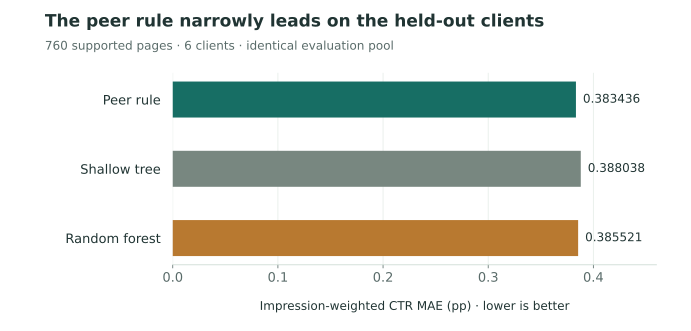

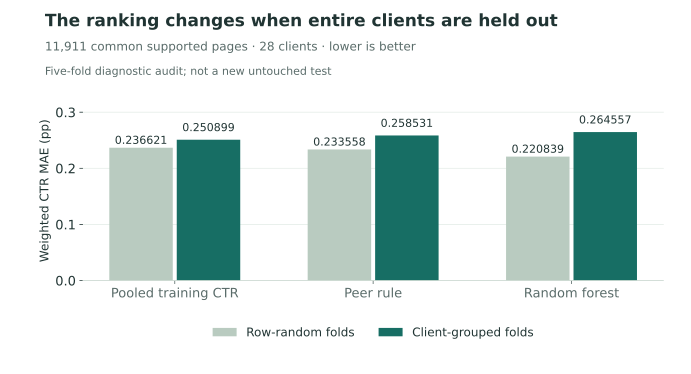

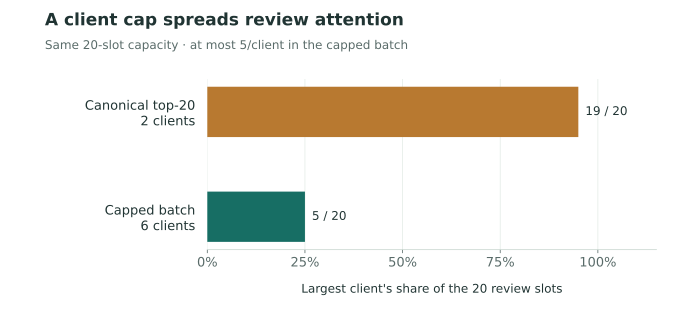

Capstone rerun wall time: 20.0 seconds (CPU-only; runtime is environment dependent).
PASS: all capstone cells, prerequisite analyses, evidence checks and static paper checks.


In [7]:
from build_paper import build, verify_site
build_receipt = build()
display(pd.DataFrame([verify_site()]))
for figure in ["holdout.svg", "split-audit.svg", "allocation.svg"]:
    display(SVG(filename=str(root / "work/figures" / figure)))
assert (root / "submission/paper_url.txt").read_text() == "https://orbin123.github.io/flyrank-ml-internship/\n"
print(f"Capstone rerun wall time: {time.perf_counter() - started:.1f} seconds (CPU-only; runtime is environment dependent).")
print("PASS: all capstone cells, prerequisite analyses, evidence checks and static paper checks.")

## Acknowledgments & data credit

[Built on the FlyRank ML Internship dataset](https://flyrank.ai). Thanks to FlyRank and the internship teaching team for the approved data and starter foundations. Data use follows [DATA_USE.md](../../DATA_USE.md): research/education only, no re-identification and no raw warehouse redistribution. Prepared with AI assistance; Orbin Sunny is responsible for the artifact. pandas, NumPy, scikit-learn, Matplotlib and Jupyter support the implementation.

## Self-check

A successful executed run is the evidence for all local checks: question/data/method/results/limits/recommendations filled; nine paper sections including abstract and data credit; input and source receipt agreement; top-to-bottom prerequisite execution; charts/tables generated; public outputs aggregate-only; exact URL format verified. The live URL and saved portal submission are verified outside the notebook after publication.

## 8. ML-12 — Five-minute demo outline

**0:00–0:35 · Question.** FlyRank has more visible, low-click content than an editor can inspect in one review cycle. I asked whether a learned CTR benchmark could prioritize that review work better than a transparent peer rule, without treating low CTR as proof that a page needs editing.

**0:35–1:25 · Method.** I used the approved anonymized 30,000-page starter snapshot and retained 12,009 pages across 28 clients under declared exposure and position rules. I compared a training-only content-type/position peer rule with a shallow tree and random forest using only average position, content type and update age; clients were kept disjoint across train, validation and test, and exposure-weighted CTR MAE was fixed as the selection metric.

**1:25–2:35 · One chart.** Show the holdout comparison above (Figure 1): peer rule **0.383436 pp**, tree **0.388038 pp**, forest **0.385521 pp** on the same 760 supported pages from six held-out clients. Explain that lower is better and that the visible differences are small, descriptive and not evidence of editorial usefulness.

**2:35–3:35 · One honest result.** The learned models did not earn promotion: the peer rule won the declared validation objective and narrowly led the original holdout. A later grouped audit made the caution stronger because a naive pooled-training CTR reference beat both contextual methods on grouped weighted MAE. The study estimates same-window CTR; it does not measure whether an editor accepts a recommendation or whether an edit improves future traffic.

**3:35–4:40 · One recommendation.** Keep the interpretable peer-gap queue as a research instrument, cap a 20-page review batch at five pages per client, and collect blinded accept/reject/defer judgments against naive and impressions-only controls. Only a later owner-approved prospective pilot with a separate outcome window should test edit effects.

**4:40–5:00 · Close.** The useful result is not that a complex model won; it is that honest client-held-out evaluation prevented an unjustified deployment and produced a concrete next experiment for FlyRank's content-review workflow. Invite questions and open the [live paper](https://orbin123.github.io/flyrank-ml-internship/).

### Shareable cut 1 — Social post

I tested whether machine learning could help prioritize FlyRank content for CTR review—and the honest result was that the complex models did **not** beat a transparent peer rule on the metric I chose in advance. Using an anonymized 30,000-page snapshot, I compared a peer benchmark, shallow tree and random forest with client-disjoint validation; holdout weighted MAE was 0.383436 pp for the rule versus 0.385521 pp for the forest. The outcome is a human-review research queue and a better next experiment, not an automated editing claim. Method, chart, limitations and reproducible notebook: https://orbin123.github.io/flyrank-ml-internship/

### Shareable cut 2 — Employer-facing summary

I built a reproducible CTR opportunity-scoring study and human-review playbook for prioritizing content inspection across a large search portfolio. I evaluated a peer rule, shallow decision tree and random forest on an anonymized 30,000-page FlyRank starter snapshot, using leakage checks and client-disjoint train/validation/test splits. The transparent rule narrowly beat the learned models on the declared exposure-weighted holdout objective (0.383436 pp versus 0.385521 pp for the forest), so I recommended a capped, labeled human-review pilot instead of model deployment.